In [1]:
import numpy as np
import matplotlib.pyplot as plt


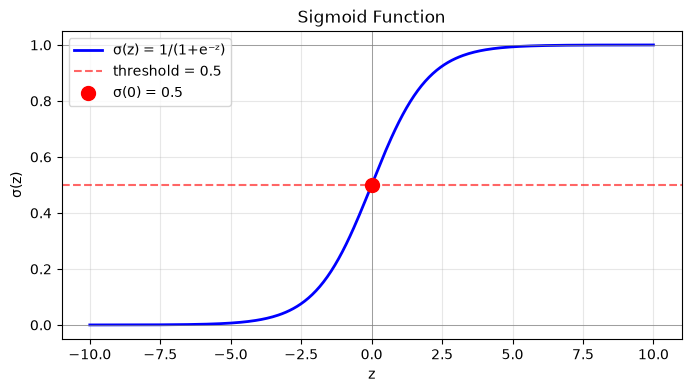

σ(-10) = 0.000045  → close to 0 (predict class 0)
σ(0)   = 0.500000  → exactly 0.5 (decision boundary)
σ(10)  = 0.999955  → close to 1 (predict class 1)


In [2]:
# Cell 2 — Version 1: sigmoid function visualised
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 300)

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z), 'b-', linewidth=2, label='σ(z) = 1/(1+e⁻ᶻ)')
plt.axhline(0.5, color='red',  linestyle='--', alpha=0.6, label='threshold = 0.5')
plt.axhline(0,   color='gray', linestyle='-',  linewidth=0.5)
plt.axhline(1,   color='gray', linestyle='-',  linewidth=0.5)
plt.axvline(0,   color='gray', linestyle='-',  linewidth=0.5)
plt.scatter([0], [0.5], s=100, color='red', zorder=5, label='σ(0) = 0.5')
plt.xlabel('z'); plt.ylabel('σ(z)')
plt.title('Sigmoid Function'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# key observations
print(f"σ(-10) = {sigmoid(-10):.6f}  → close to 0 (predict class 0)")
print(f"σ(0)   = {sigmoid(0):.6f}  → exactly 0.5 (decision boundary)")
print(f"σ(10)  = {sigmoid(10):.6f}  → close to 1 (predict class 1)")

Good predictions loss: 0.1639
Bad  predictions loss: 1.0581
Lower loss = better model ✅


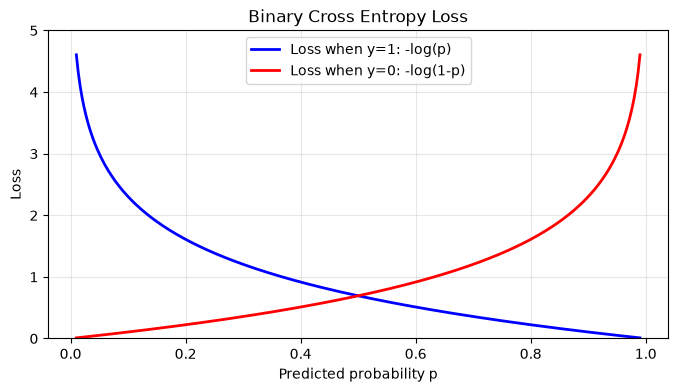

In [3]:
# Cell 3 — Version 2: cross entropy loss
# Binary Cross Entropy: L = -[y*log(p) + (1-y)*log(1-p)]
# y = actual label (0 or 1), p = predicted probability

def binary_cross_entropy(y_actual, y_pred_prob):
    epsilon = 1e-9   # avoid log(0)
    return -np.mean(y_actual * np.log(y_pred_prob + epsilon) +
                    (1 - y_actual) * np.log(1 - y_pred_prob + epsilon))

# example: 5 samples
y_actual   = np.array([1, 1, 0, 0, 1])
y_pred_good = np.array([0.9, 0.8, 0.1, 0.2, 0.85])  # confident + correct
y_pred_bad  = np.array([0.3, 0.4, 0.7, 0.6, 0.35])  # wrong predictions

print(f"Good predictions loss: {binary_cross_entropy(y_actual, y_pred_good):.4f}")
print(f"Bad  predictions loss: {binary_cross_entropy(y_actual, y_pred_bad):.4f}")
print("Lower loss = better model ✅")

# visualise how loss changes with predicted probability
p = np.linspace(0.01, 0.99, 300)
loss_y1 = -np.log(p)        # loss when actual y=1
loss_y0 = -np.log(1 - p)   # loss when actual y=0

plt.figure(figsize=(8, 4))
plt.plot(p, loss_y1, 'b-', linewidth=2, label='Loss when y=1: -log(p)')
plt.plot(p, loss_y0, 'r-', linewidth=2, label='Loss when y=0: -log(1-p)')
plt.xlabel('Predicted probability p')
plt.ylabel('Loss')
plt.title('Binary Cross Entropy Loss')
plt.legend(); plt.grid(True, alpha=0.3); plt.ylim(0, 5)
plt.show()

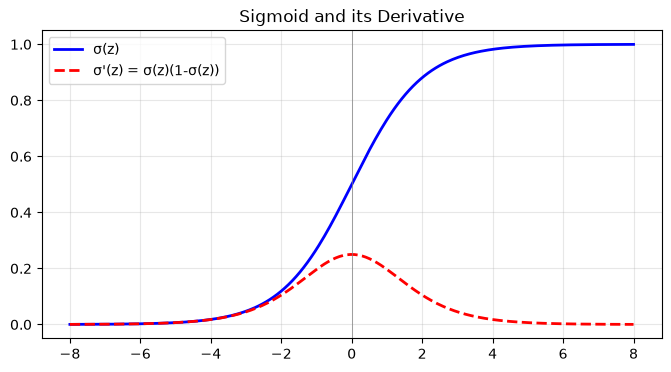

Max gradient at z=0: 0.2500
Gradient near 0 → vanishing gradient problem in deep nets!


In [4]:
# Cell 4 — Version 3: sigmoid derivative (used in backprop)
# d/dz σ(z) = σ(z) * (1 - σ(z))

def sigmoid(z):      return 1 / (1 + np.exp(-z))
def sigmoid_grad(z): return sigmoid(z) * (1 - sigmoid(z))

z = np.linspace(-8, 8, 300)

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z),      'b-',  linewidth=2, label='σ(z)')
plt.plot(z, sigmoid_grad(z), 'r--', linewidth=2, label="σ'(z) = σ(z)(1-σ(z))")
plt.axvline(0, color='gray', linewidth=0.5)
plt.title('Sigmoid and its Derivative')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print(f"Max gradient at z=0: {sigmoid_grad(0):.4f}")  # = 0.25
print("Gradient near 0 → vanishing gradient problem in deep nets!")

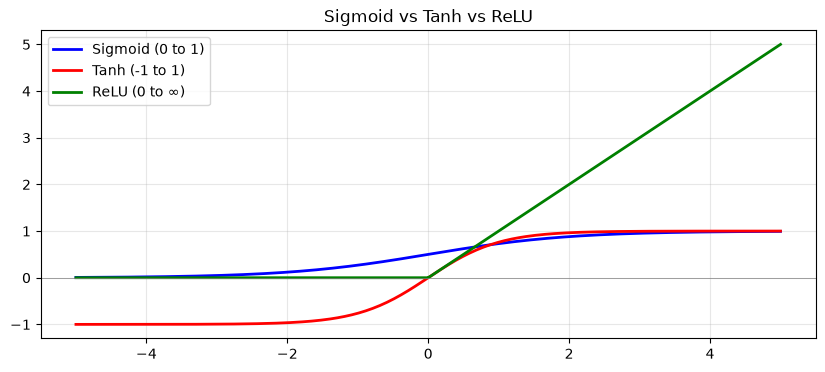

In [5]:
# Cell 5 — Version 4: compare sigmoid vs other activation functions
def sigmoid(z):  return 1 / (1 + np.exp(-z))
def tanh(z):     return np.tanh(z)
def relu(z):     return np.maximum(0, z)

z = np.linspace(-5, 5, 300)

plt.figure(figsize=(10, 4))
plt.plot(z, sigmoid(z), 'b-',  linewidth=2, label='Sigmoid (0 to 1)')
plt.plot(z, tanh(z),    'r-',  linewidth=2, label='Tanh (-1 to 1)')
plt.plot(z, relu(z),    'g-',  linewidth=2, label='ReLU (0 to ∞)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.title('Sigmoid vs Tanh vs ReLU')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()